# Unidade II — Análise de Dados

## Visualização de dados

**Carga estimada:** 3 horas  
**Pré-requisitos:** notebook 02.01 e manipulação básica com pandas.

> **Pergunta norteadora:** qual representação visual responde à pergunta sem distorcer os dados nem excluir parte do público?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- escolher gráficos coerentes com tipo de atributo e pergunta;
- interpretar distribuição, associação e comparação entre grupos;
- construir gráficos com títulos, eixos, unidades e legendas adequados;
- reconhecer escalas e escolhas visuais potencialmente enganosas;
- aplicar princípios básicos de acessibilidade.


## Pergunta, variável e marca visual

Um gráfico deve começar por uma pergunta. Quantidades podem ser codificadas por posição e comprimento; categorias, por posição, forma ou cor; tempo, normalmente por posição ordenada. Posição em escala comum costuma permitir comparação mais precisa que área, volume ou ângulo.

| Pergunta | Estrutura | Gráfico inicial possível |
|---|---|---|
| Como uma variável numérica se distribui? | uma numérica | histograma e boxplot |
| Como categorias se comparam? | uma categórica e uma contagem | barras |
| Duas numéricas se associam? | duas numéricas | dispersão |
| Como uma numérica varia entre grupos? | numérica e categórica | boxplot, violino ou pontos |
| Como várias numéricas se relacionam? | matriz numérica | mapa de calor de correlações |

A tabela não é uma regra automática: tamanho da amostra, sobreposição, incerteza e finalidade de comunicação também importam.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 120})

iris = load_iris(as_frame=True)
dados = iris.frame.rename(columns={"target": "especie_codigo"})
dados["especie"] = dados["especie_codigo"].map(dict(enumerate(iris.target_names)))
dados.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie_codigo,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Distribuição de uma variável

O histograma divide a escala em intervalos e conta observações. A forma depende da largura e da origem dos intervalos; portanto, diferentes escolhas de `bins` podem revelar ou ocultar estrutura. O boxplot resume mediana, quartis e observações além de limites convencionais, mas não mostra toda a forma da distribuição.


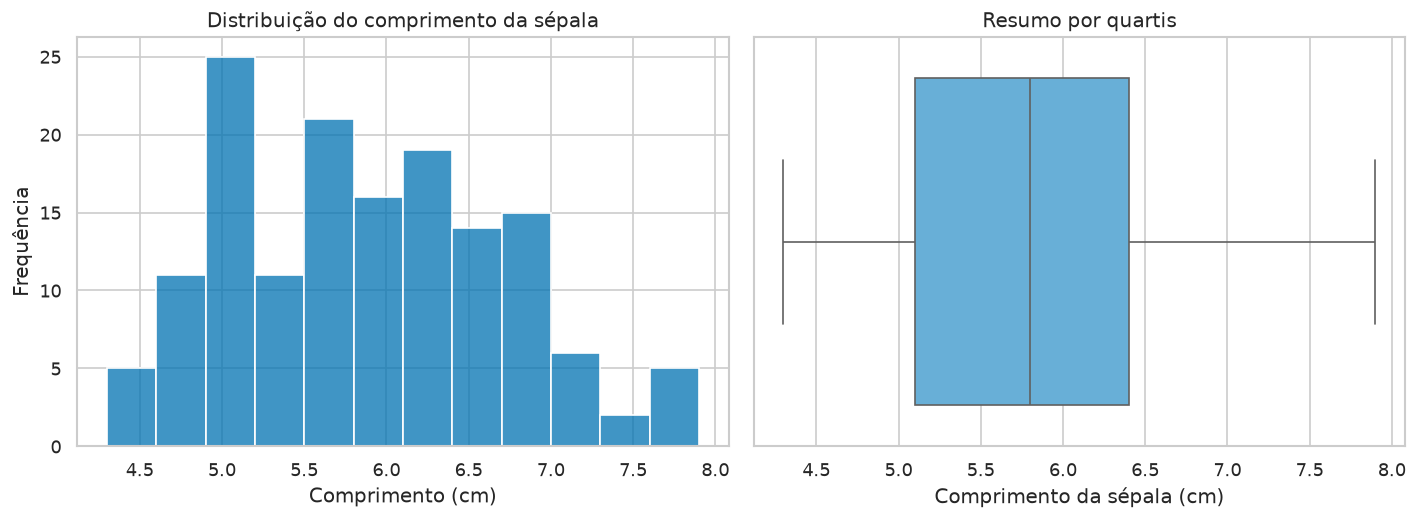

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)
sns.histplot(data=dados, x="sepal length (cm)", bins=12, color="#0072B2", ax=axes[0])
axes[0].set(title="Distribuição do comprimento da sépala", xlabel="Comprimento (cm)", ylabel="Frequência")
sns.boxplot(data=dados, x="sepal length (cm)", color="#56B4E9", ax=axes[1])
axes[1].set(title="Resumo por quartis", xlabel="Comprimento da sépala (cm)", ylabel="")
fig.tight_layout()
plt.show()


O histograma sugere concentração central e alguma assimetria, enquanto o boxplot destaca posição e dispersão. Nenhum deles mostra que os dados reúnem três espécies; uma distribuição agregada pode esconder subgrupos.

## Comparação entre grupos

Separar por espécie responde se as distribuições diferem entre categorias. Um boxplot facilita comparar mediana e IQR, mas deve ser interpretado junto ao tamanho dos grupos e à forma dos dados.


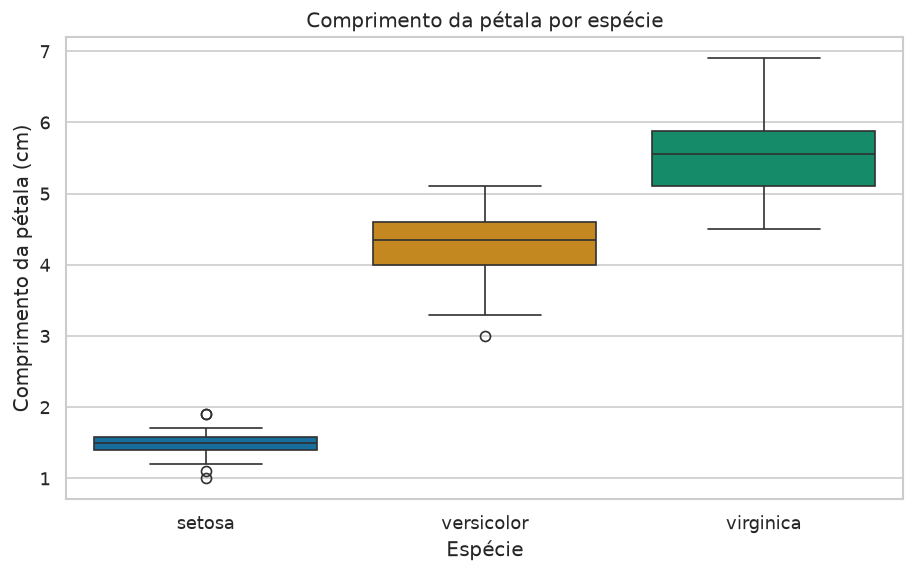

In [3]:
fig, ax = plt.subplots()
sns.boxplot(data=dados, x="especie", y="petal length (cm)", hue="especie", palette="colorblind", legend=False, ax=ax)
ax.set(title="Comprimento da pétala por espécie", xlabel="Espécie", ylabel="Comprimento da pétala (cm)")
plt.show()


As pétalas de *setosa* são menores, e *versicolor* e *virginica* mostram separação parcial. O gráfico descreve a amostra; não demonstra que pertencer a uma espécie causa mecanicamente um comprimento específico.

## Associação entre variáveis numéricas

O gráfico de dispersão preserva observações individuais e ajuda a perceber direção, forma, intensidade, grupos e casos incomuns. Cor e marcador serão usados juntos para que a distinção não dependa somente de cor.


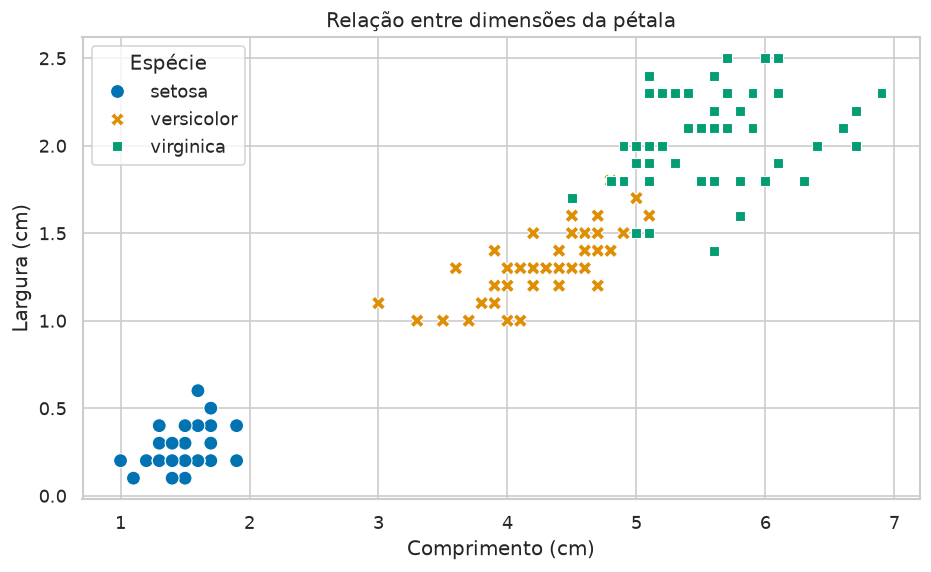

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(
    data=dados, x="petal length (cm)", y="petal width (cm)",
    hue="especie", style="especie", palette="colorblind", s=70, ax=ax,
)
ax.set(title="Relação entre dimensões da pétala", xlabel="Comprimento (cm)", ylabel="Largura (cm)")
ax.legend(title="Espécie")
plt.show()


Há associação positiva forte entre comprimento e largura da pétala, além de grupos associados às espécies. A correlação agregada mistura variação dentro e entre espécies; sempre examine o gráfico e o contexto.

### Mapa de calor de correlações

O mapa de calor resume muitos pares, mas não substitui os gráficos de dispersão: ele reduz cada relação a um coeficiente linear.


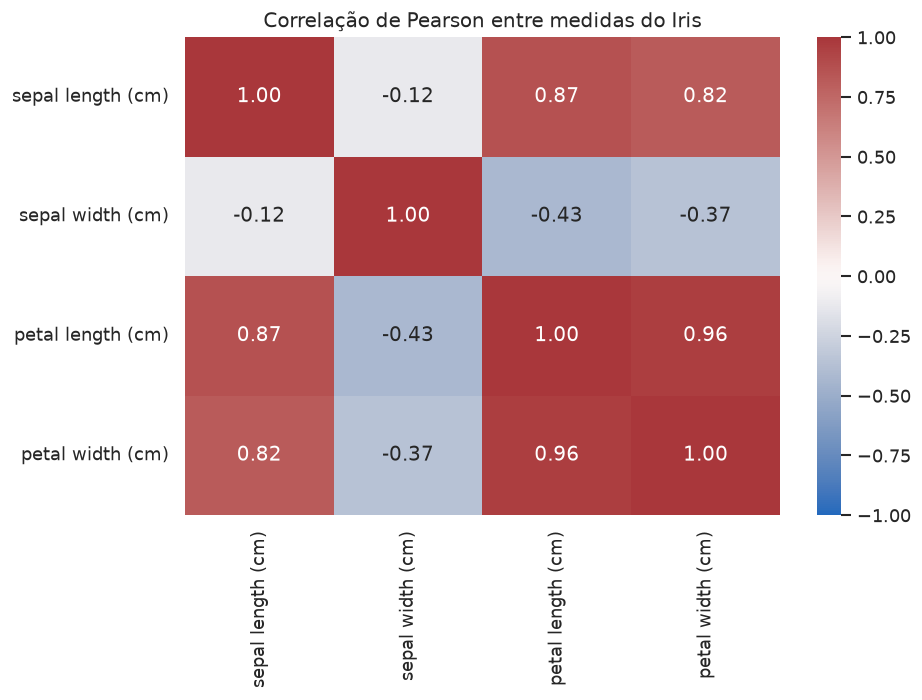

In [5]:
colunas_numericas = iris.feature_names
correlacoes = dados[colunas_numericas].corr()
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson entre medidas do Iris")
fig.tight_layout()
plt.show()


## Escolhas enganosas e acessibilidade

Em gráficos de barras, o comprimento representa magnitude e a base normalmente deve começar em zero. Cortar o eixo pode exagerar pequenas diferenças. Em séries e dispersões, zero nem sempre é obrigatório, mas o domínio exibido deve ser justificável e explícito. Também evite área 3D, excesso de categorias, cores sem contraste e paletas que atribuam ordem inexistente.

Checklist mínimo:

- título descreve a pergunta ou conclusão sem exagero;
- eixos têm nomes e unidades;
- escalas, filtros e agregações são informados;
- cor não é o único canal para informação essencial;
- valores importantes também são descritos em texto;
- legenda acrescenta informação e não repete o óbvio.

> **Verifique seu entendimento:** por que um gráfico de barras com eixo vertical iniciado em 98 pode exagerar uma diferença entre valores 99 e 100?

> **Exercício:** escolha duas perguntas diferentes sobre o Iris. Para cada pergunta, produza um gráfico, justifique a escolha da representação e escreva uma interpretação de três frases que mencione padrão, limitação e o que não pode ser concluído.


## Síntese

- A pergunta e os tipos dos atributos orientam a representação.
- Histogramas e boxplots oferecem visões complementares da distribuição.
- Dispersão revela forma e grupos que um coeficiente pode ocultar.
- Escalas, agregações e canais visuais podem distorcer comparações.
- Um gráfico de qualidade é legível, acessível e acompanhado de interpretação.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 2, seção 2.2.4.
- WILKE, Claus O. *Fundamentals of Data Visualization*. Sebastopol: O’Reilly, 2019.
